# Rep. 4. Checkpoint 5. Exóticas: Asiáticas y con Barrera

Gonzalo Cano Padilla

## Asiaticas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


# Parámetros

S0 = 670
K = 680
r = 0.04
sigma = 0.17
N = 30          # numero de días
T = N/365       # tiempo al venc.
M = 10000       # numero de simulaciones
dt = T/N

Z = np.random.standard_normal((M,N))

retornos = (r - 0.5 * sigma ** 2) * dt + sigma * np.sqrt(dt) * Z

S_paths = S0 * np.exp(np.cumsum(retornos, axis = 1))
S_paths = np.insert(S_paths, 0, S0, axis = 1)

# vector de precios al vencimiento
ST = S_paths[:,-1]
# vector de precios promedio de fluctuacion del subyacente
S_media = S_paths.mean(axis=1)

europea = np.exp(-r * T) * np.maximum(ST - K, 0)
asiatica = np.exp(-r * T) * np.maximum(S_media - K, 0)

# analítica Black Scholes
d1 = (np.log(S0 / K) + (r + 0.5 * sigma **2) * T / sigma * np.sqrt(T))
d2 = d1 - sigma * np.sqrt(T)
bs_call = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

print("Precio Asiatica:",asiatica.mean())
print("Precio Europea:",europea.mean())
print("Precio Black Scholes:",bs_call)


Precio Asiatica: 3.9650839040398447
Precio Europea: 9.663412149810789
Precio Black Scholes: 9.308744964731545


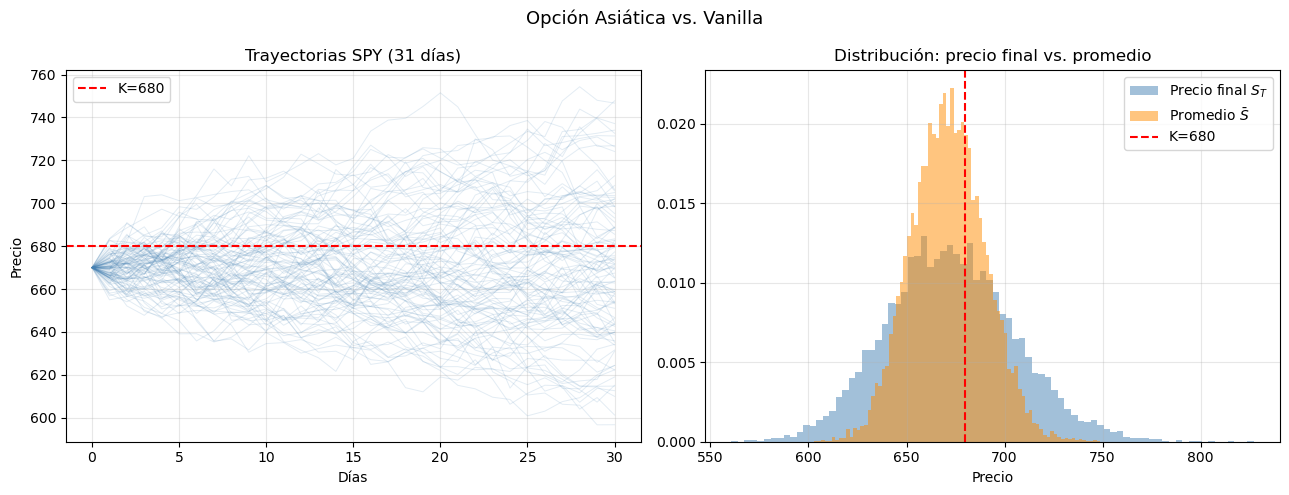

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Trayectorias con el promedio marcado
for i in range(100):
    axes[0].plot(S_paths[i], alpha=0.15, linewidth=0.7, color='steelblue')
axes[0].axhline(K, color='red', linestyle='--', linewidth=1.5, label=f'K={K}')
axes[0].set_title('Trayectorias SPY (31 días)')
axes[0].set_xlabel('Días')
axes[0].set_ylabel('Precio')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribución: precio final vs. promedio
axes[1].hist(ST,      bins=80, density=True, alpha=0.5,
             color='steelblue', label='Precio final $S_T$')
axes[1].hist(S_media, bins=80, density=True, alpha=0.5,
             color='darkorange', label='Promedio $\\bar{S}$')
axes[1].axvline(K, color='red', linestyle='--', label=f'K={K}')
axes[1].set_title('Distribución: precio final vs. promedio')
axes[1].set_xlabel('Precio')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Opción Asiática vs. Vanilla', fontsize=13)
plt.tight_layout()
plt.show()

## Opciones con Barrera

In [3]:
B_up = 710

S_max = S_paths.max(axis=1)


# up and out
activa_up_and_out = (S_max < B_up)
call_up_and_out = np.exp(-r * T) * np.maximum(ST - K, 0) * activa_up_and_out

# up and out
activa_up_and_in = (S_max > B_up)
call_up_and_in = np.exp(-r * T) * np.maximum(ST - K, 0) * activa_up_and_in

print("up and out: ", call_up_and_out.mean())
print("up and in: ", call_up_and_in.mean())
print("europea", europea.mean())
print("comprobacion", call_up_and_out.mean() + call_up_and_in.mean()  )

up and out:  2.262939619431136
up and in:  7.400472530379653
europea 9.663412149810789
comprobacion 9.663412149810789


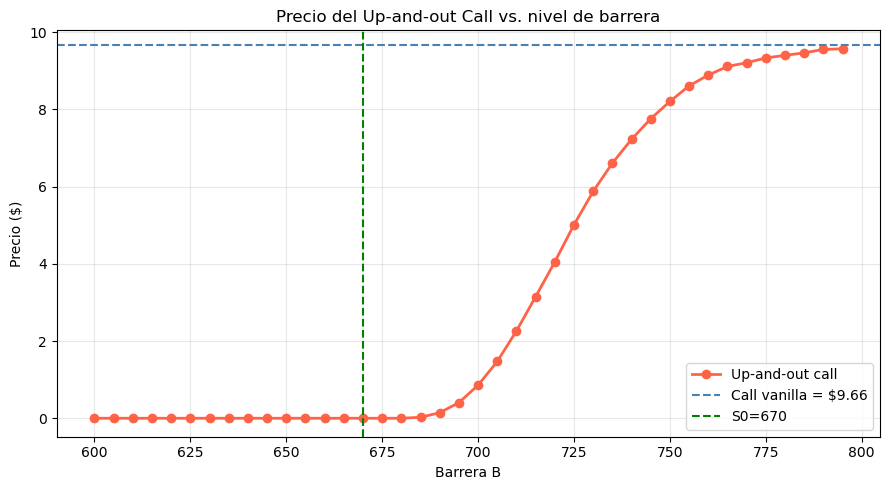

In [4]:
B_range = np.arange(600, 800, 5)   # barreras superiores
precios_uao = []

for b in B_range:
    s_max_b = S_paths.max(axis=1)
    precio  = np.exp(-r*T) * np.maximum(ST - K, 0) * (s_max_b < b)
    precios_uao.append(precio.mean())

plt.figure(figsize=(9, 5))
plt.plot(B_range, precios_uao, color='tomato', linewidth=2, marker='o',
         label='Up-and-out call')
plt.axhline(europea.mean(), color='steelblue', linestyle='--',
            linewidth=1.5, label=f'Call vanilla = ${europea.mean():.2f}')
plt.axvline(S0, color='green', linestyle='--', label=f'S0={S0}')
plt.xlabel('Barrera B')
plt.ylabel('Precio ($)')
plt.title('Precio del Up-and-out Call vs. nivel de barrera')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Preguntas de reflexión

---

**1. ¿Por qué el ejercicio anticipado de una call sobre un activo sin dividendos nunca es óptimo? ¿Qué cambia si el activo paga dividendos?**

Porque ejercer antes implica renunciar al valor del tiempo que aún tiene la opción. Además, al pagar el strike K hoy en lugar de al vencimiento, dejas de ganar intereses sobre ese capital. Siempre conviene más vender la call que ejercerla. Si el activo paga dividendos, el precio cae el día ex-dividendo y eso reduce el valor de la call, por lo que puede convenir ejercer justo antes para capturar ese flujo.

---

**2. En la gráfica de convergencia, ¿por qué el precio oscila antes de converger? ¿Qué relación tiene eso con si N es par o impar?**

Cuando N es par, existe un nodo central al vencimiento que cae exactamente en S0; cuando N es impar, ese nodo se desplaza levemente. Eso hace que el payoff estimado sea sistemáticamente distinto en cada caso, produciendo una oscilación alternante conforme N crece. Con N suficientemente grande, ambas secuencias convergen al mismo precio y la oscilación desaparece.

---

**3. La prima por ejercicio anticipado es mayor para puts muy ITM. ¿Por qué intuitivamente tiene sentido ejercer anticipadamente una put muy ITM?**

Si el subyacente cae mucho por debajo del strike (por ejemplo S=580, K=680), el valor intrínseco ya es muy alto y el potencial de seguir ganando es limitado porque S no puede bajar de cero. Ejercer hoy te permite recibir K − S de inmediato e invertirlo a la tasa libre de riesgo, lo cual vale más que seguir esperando con casi nada de optionalidad adicional.

---

**4. Si modificas T primero a 31 días y luego a 1 año, ¿cómo esperas que cambie la diferencia entre la put americana y la europea? ¿Por qué?**

La diferencia aumenta con T. A mayor plazo, hay más oportunidades para que el subyacente caiga profundamente ITM y más tiempo para acumular el interés sobre K − S al ejercer anticipadamente. La put europea no puede aprovechar ese momento óptimo; la americana sí. Por eso la prima de ejercicio anticipado crece con el horizonte.

---

**5. El árbol CRR usa probabilidades neutrales al riesgo p, no probabilidades reales. ¿Qué significa eso y por qué es válido para el pricing?**

Las probabilidades neutrales al riesgo no describen la frecuencia real con que el activo sube o baja; son una construcción matemática que hace que el activo crezca exactamente a la tasa libre de riesgo r en promedio. Son válidas porque, bajo el argumento de no-arbitraje, el precio de cualquier derivado es el costo de replicarlo con el activo y el bono, y ese costo no depende de cuánto retorno espera el mercado, sino solo de r. Las probabilidades reales (con el retorno esperado real) se cancelan en el proceso de replicación.